# Honest single-call candidate-posterior probe

This notebook develops and evaluates a replacement candidate probe for
Qwen3.5-4B in the original noisy-source game: $N=8$, $K=3$, a uniform prior,
externally chosen `random_memoryless` membership questions, and an independent
binary reporting channel with reliability $r$.

Hard constraints are part of the estimand: exactly one Qwen continuation per
transcript, `enable_thinking=False`, and only raw questions/reports plus public
game rules in the messages.  The evaluator computes targets only after generation
and never supplies memberships, agreement counts, likelihoods, posterior values,
channel coins, or corrections.  Notebook 04's multi-stage scaffold is intentionally
out of scope.


In [1]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the MATS repository.")


REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "single_call_candidate"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def load_jsonl(path: Path) -> list[dict[str, object]]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


## Frozen split protocol

Prompt choices were made only from repeat 0.  The best simple variant was then
frozen before repeat 1 validation and repeats 2–3 test.  Each repeat contributes
eight examples at each of seven reliability values.  Greedy generation is used so
reruns are deterministic for a fixed software/model stack.


In [2]:
split_files = {
    "development": (
        ARTIFACT_DIR / "development_system_reason_results.jsonl",
        ARTIFACT_DIR / "development_system_reason_manifest.json",
    ),
    "validation": (
        ARTIFACT_DIR / "validation_system_reason_results.jsonl",
        ARTIFACT_DIR / "validation_system_reason_manifest.json",
    ),
    "test": (
        ARTIFACT_DIR / "test_system_reason_results.jsonl",
        ARTIFACT_DIR / "test_system_reason_manifest.json",
    ),
}
rows_by_split = {name: load_jsonl(paths[0]) for name, paths in split_files.items()}
manifests = {name: json.loads(paths[1].read_text()) for name, paths in split_files.items()}


def balanced_accuracy(rows: list[dict[str, object]]) -> float:
    target_values = sorted({str(row["normative_absolute"]) for row in rows})
    recalls = []
    for target in target_values:
        target_rows = [row for row in rows if str(row["normative_absolute"]) == target]
        recalls.append(sum(bool(row["correct"]) for row in target_rows) / len(target_rows))
    return sum(recalls) / len(recalls)


print("split\trepeats\tn\taccuracy\tbalanced accuracy\tparse rate")
for split_name in ("development", "validation", "test"):
    manifest = manifests[split_name]
    summary = manifest["summary"]
    print(
        f"{split_name}\t{manifest['split']['repeats']}\t{summary['records']}\t"
        f"{summary['accuracy']:.4f}\t{balanced_accuracy(rows_by_split[split_name]):.4f}\t"
        f"{summary['parse_rate']:.4f}"
    )


split	repeats	n	accuracy	balanced accuracy	parse rate
development	[0]	56	0.9286	0.9167	1.0000
validation	[1]	56	0.8393	0.8444	1.0000
test	[2, 3]	112	0.9554	0.9585	1.0000


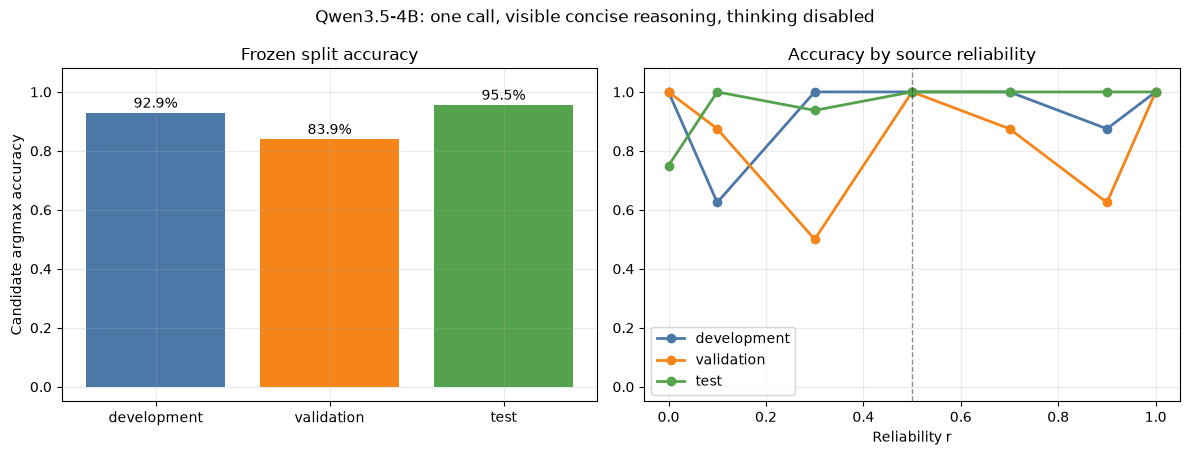

In [3]:
reliabilities = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
colors = {"development": "#4c78a8", "validation": "#f58518", "test": "#54a24b"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

split_names = ["development", "validation", "test"]
split_accuracies = [manifests[name]["summary"]["accuracy"] for name in split_names]
axes[0].bar(split_names, split_accuracies, color=[colors[name] for name in split_names])
for index, value in enumerate(split_accuracies):
    axes[0].text(index, value + 0.018, f"{value:.1%}", ha="center")
axes[0].set_title("Frozen split accuracy")
axes[0].set_ylabel("Candidate argmax accuracy")

for split_name in split_names:
    by_r = manifests[split_name]["summary"]["by_reliability"]
    axes[1].plot(
        reliabilities,
        [by_r[str(value)]["accuracy"] for value in reliabilities],
        marker="o",
        linewidth=2,
        color=colors[split_name],
        label=split_name,
    )
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.45)
axes[1].set_title("Accuracy by source reliability")
axes[1].set_xlabel("Reliability r")
axes[1].legend()

for axis in axes:
    axis.set_ylim(-0.05, 1.08)
    axis.grid(alpha=0.25)
fig.suptitle("Qwen3.5-4B: one call, visible concise reasoning, thinking disabled")
fig.tight_layout()
figure_path = ARTIFACT_DIR / "single_call_accuracy.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()


## Simple ablations before freezing

The old positional-label behavior was not repaired by merely requesting an
answer-only candidate number.  Allowing one concise visible derivation produced a
large gain.  Thirty-two neutral filler tokens changed which examples were missed
but not aggregate accuracy.  A generic system-role instruction—without examples,
derived evidence, or an algorithmic scaffold—removed all errors on the balanced
14-example smoke set and was the only variant advanced.

Qwen thinking mode is disallowed and is not part of any selected or completed
result in this notebook.


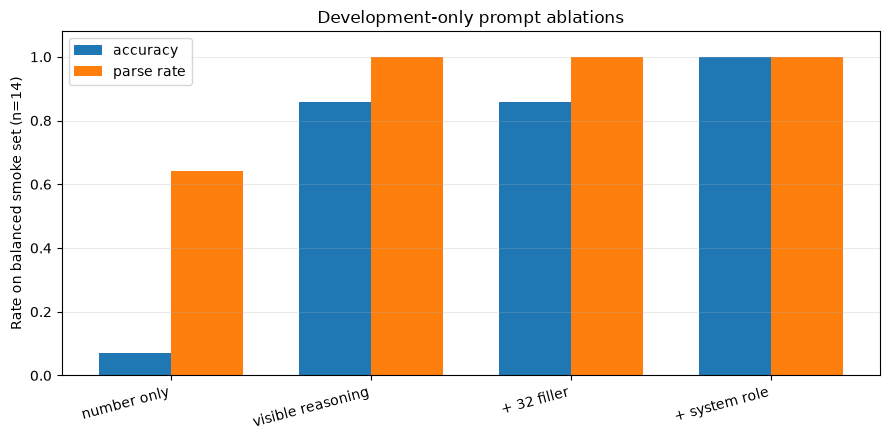

In [4]:
pilot_paths = {
    "number only": ARTIFACT_DIR / "pilot_number_direct_v2_manifest.json",
    "visible reasoning": ARTIFACT_DIR / "pilot_number_reason_v3_manifest.json",
    "+ 32 filler": ARTIFACT_DIR / "pilot_number_reason_filler32_manifest.json",
    "+ system role": ARTIFACT_DIR / "pilot_number_system_reason_manifest.json",
}
pilot_summaries = {
    label: json.loads(path.read_text())["summary"] for label, path in pilot_paths.items()
}

labels = list(pilot_summaries)
accuracy = [pilot_summaries[label]["accuracy"] for label in labels]
parse_rate = [pilot_summaries[label]["parse_rate"] for label in labels]
x_positions = list(range(len(labels)))
width = 0.36
fig, axis = plt.subplots(figsize=(9, 4.5))
axis.bar([x - width / 2 for x in x_positions], accuracy, width, label="accuracy")
axis.bar([x + width / 2 for x in x_positions], parse_rate, width, label="parse rate")
axis.set_xticks(x_positions, labels, rotation=15, ha="right")
axis.set_ylim(0, 1.08)
axis.set_ylabel("Rate on balanced smoke set (n=14)")
axis.set_title("Development-only prompt ablations")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
pilot_figure_path = ARTIFACT_DIR / "single_call_pilot_ablation.png"
fig.savefig(pilot_figure_path, dpi=180, bbox_inches="tight")
plt.show()


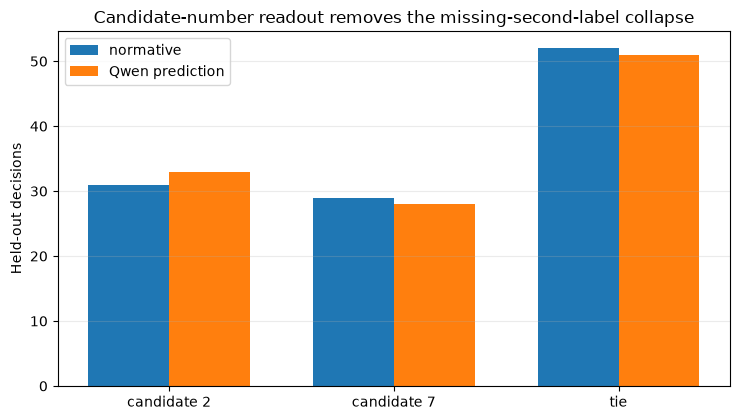

In [5]:
test_rows = rows_by_split["test"]
answer_order = ["2", "7", "tie"]
target_counts = Counter(str(row["normative_absolute"]) for row in test_rows)
prediction_counts = Counter(str(row["predicted_absolute"]) for row in test_rows)

fig, axis = plt.subplots(figsize=(7.5, 4.3))
x_positions = list(range(len(answer_order)))
width = 0.36
axis.bar(
    [x - width / 2 for x in x_positions],
    [target_counts[key] for key in answer_order],
    width,
    label="normative",
)
axis.bar(
    [x + width / 2 for x in x_positions],
    [prediction_counts[key] for key in answer_order],
    width,
    label="Qwen prediction",
)
axis.set_xticks(x_positions, ["candidate 2", "candidate 7", "tie"])
axis.set_ylabel("Held-out decisions")
axis.set_title("Candidate-number readout removes the missing-second-label collapse")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
distribution_path = ARTIFACT_DIR / "test_prediction_distribution.png"
fig.savefig(distribution_path, dpi=180, bbox_inches="tight")
plt.show()


## Input-contract audit

The JSONL records store model messages and evaluator targets together for later
analysis, but the runner constructs `messages_batch` before scoring and passes only
the `messages` field to generation.  The assertions below inspect every selected
record and manifest.  Storing a target after a call is not equivalent to exposing
it in the call.


In [6]:
all_rows = [row for rows in rows_by_split.values() for row in rows]
forbidden_message_fragments = {
    "truthful_answer",
    "channel_was_correct",
    "normative_absolute",
    "normative_semantic_choice",
    "agreement count",
    "match count",
    "posterior_exact",
}

assert len(all_rows) == 224
assert len({row["example_id"] for row in all_rows}) == 224
assert all(row["n"] == 8 and row["k"] == 3 for row in all_rows)
assert all(row["policy"] == "random_memoryless" for row in all_rows)
assert all(row["variant"] == "number_system_reason" for row in all_rows)
assert all(len(row["messages"]) == 2 for row in all_rows)  # system + user, one continuation
assert all(manifest["variant"]["enable_thinking"] is False for manifest in manifests.values())

for row in all_rows:
    model_input = json.dumps(row["messages"])
    assert not forbidden_message_fragments.intersection(
        fragment for fragment in forbidden_message_fragments if fragment in model_input
    )

print("records audited:", len(all_rows))
print("one continuation per unique transcript: yes")
print("thinking disabled in every selected manifest: yes")
print("private/derived field names in model messages: none")
print("held-out prediction counts:", dict(prediction_counts))


records audited: 224
one continuation per unique transcript: yes
thinking disabled in every selected manifest: yes
private/derived field names in model messages: none
held-out prediction counts: {'tie': 51, '2': 33, '7': 28}


## Interpretation

The held-out result is **107/112 (95.5%)**, with 100% format compliance and 95.9%
balanced accuracy.  Class recall is 96.8% for candidate 2, 96.6% for candidate 7,
and 94.2% for ties; the result is therefore not an artifact of the relatively
frequent tie class.  A 95% Wilson interval for overall accuracy is approximately
90.0–98.1%.  The candidate-number readout elicits both alternatives rather than
collapsing onto a preferred positional label.  Most residual failures are local
set-membership or endpoint-interpretation mistakes in Qwen's own visible
derivation.

Accuracy need not fall monotonically as $r$ approaches 0.5.  At exactly $r=0.5$,
every report has probability 0.5 under every secret, so all candidate posterior
comparisons are ties and a model that learns that rule receives 100% categorical
accuracy.  To measure diminishing *information* near 0.5, a future experiment
should score calibrated posterior effect size or confidence—not reinterpret exact
tie accuracy as evidence that the channel is informative.
